In [1]:
import numpy as np                      # Importing numpy
import matplotlib.pyplot as plt         # Importing matplotlib.pyplot
import RandomTilings as RT              # Importing Important routines
import RandomTilingsV2b as RTb
from gc import collect
from time import perf_counter

Reduction	 0.9005354000255466
Shuffling	 5.179623299976811
Plotting 	 2.962278899969533
-------------------------------------
total    	 9.164961599977687


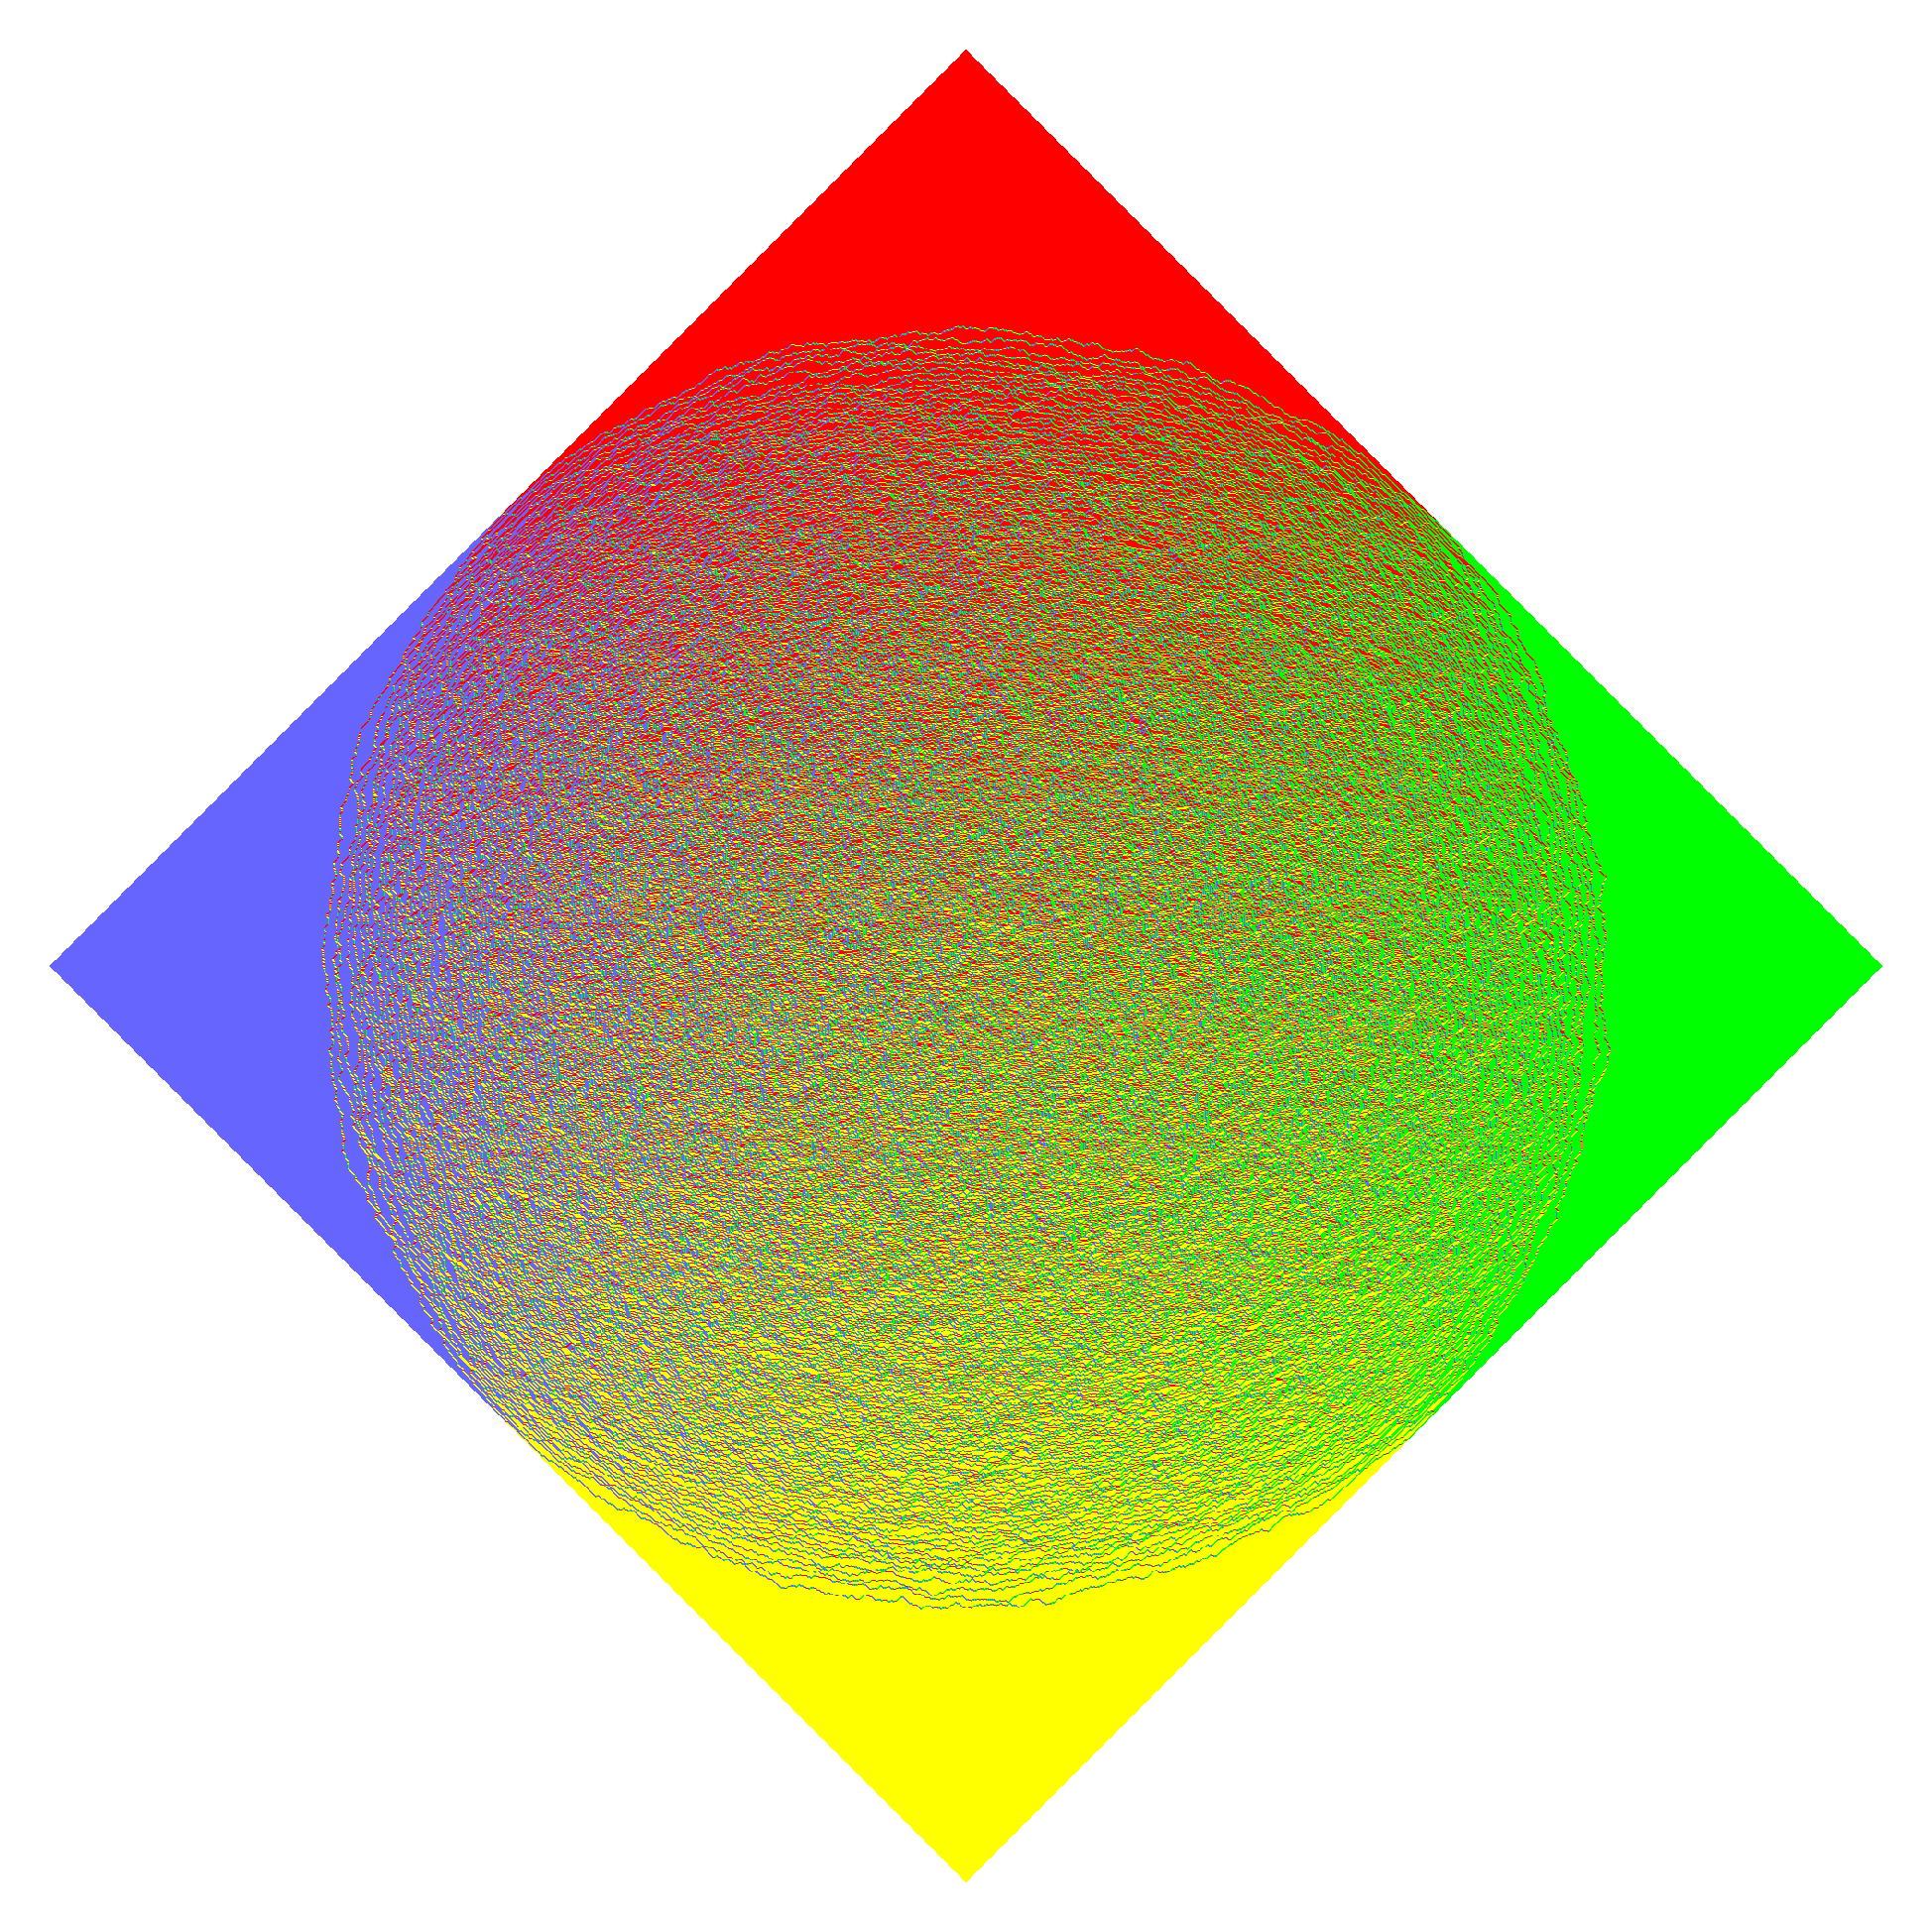

In [19]:
n = 1000
w = np.array([[1]])
t0 = perf_counter()
collect()
t1 = perf_counter()
A = RT.Aztec(n,w)
print('Reduction\t', perf_counter()-t1)
t1 = perf_counter()
A.shuffle()
print('Shuffling\t',perf_counter()-t1)
t1 = perf_counter()
A.plot(dpi=500)
print('Plotting \t',perf_counter()-t1)
print('-------------------------------------')
print('total    \t',perf_counter()-t0)

# Aztec Diamond

In [2]:
# Diasable automatic plotting
%matplotlib agg

# Get back to normal
%matplotlib inline

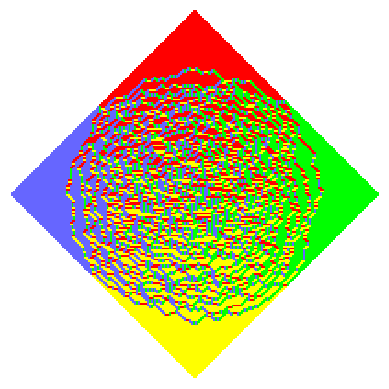

In [2]:
n = 100
w = np.array([[1]])
A = RT.Aztec(n,w)
A.shuffle()
M = A.get_M()
A.plot()

In [33]:
%matplotlib agg
from tqdm import trange

N    = trange(50,550,50)
reps = 5
T1   = []
T2   = []


dpi = 100
w = np.array([[1]])
B = RTb.Hexagon(1,w)
for n in N:
    A = RT.Hexagon(n,w)
    A.shuffle()
    M = A.get_M()
    B = RTb.Hexagon(n,w)
    B._RandomTiling__M = M
    tmpT1 = []
    tmpT2 = []
    for _ in range(reps):
        # garbage collection
        collect()
        ####
        t1 = perf_counter()
        A.plot()
        tmpT1 += [perf_counter()-t1]
        fig = A.fig
        plt.close(fig)
        del fig


        # garbage collection
        collect()
        t1 = perf_counter()
        B.plot()
        fig = B.fig
        tmpT2 += [perf_counter()-t1]
        plt.close(fig)
        del fig

    T1 += [tmpT1]
    T2 += [tmpT2]



T1 = np.array(T1)
T2 = np.array(T2)    


100%|██████████| 10/10 [05:04<00:00, 30.40s/it]


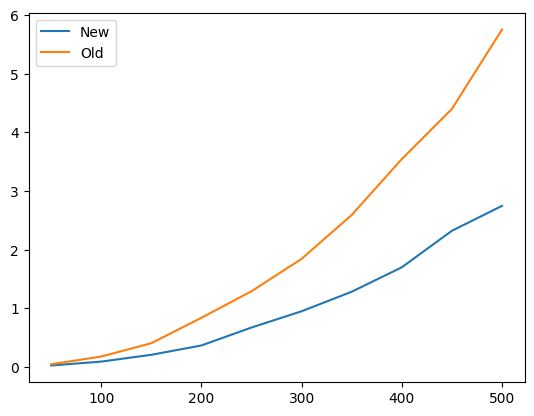

In [34]:
%matplotlib inline
plt.plot(range(50,50*(len(T1)+1),50),np.median(T1,1),label='New')
plt.plot(range(50,50*(len(T2)+1),50),np.median(T2,1),label = 'Old')
plt.legend()
plt.show()

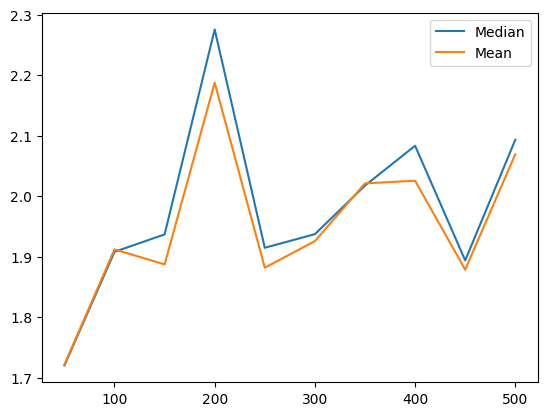

In [35]:
plt.plot(range(50,50*(len(T2)+1),50),np.median(T2,1)/np.median(T1,1), label = 'Median')
plt.plot(range(50,50*(len(T2)+1),50),np.mean(T2,1)/np.mean(T1,1), label = 'Mean')
plt.legend()
plt.show()

In [8]:
n = 1000
w = np.array([[1]])
t0 = perf_counter()
t1 = perf_counter()
A = RT.Aztec(n,w)
print('Reduction\t', perf_counter()-t1)
# t1 = perf_counter()
# A.shuffle()
# print('Shuffling\t',perf_counter()-t1)
# t1 = perf_counter()
# A.plot(dpi=500)
# print('Plotting \t',perf_counter()-t1)
# print('-------------------------------------')
# print('total    \t',perf_counter()-t0)

Reduction	 2.9457148000365123


In [15]:
A = 45
m = 2

L = np.random.random(100)

%timeit L[A+2*m]

73.6 ns ± 0.529 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [16]:
I = A+2*m
%timeit L[I] 

56.4 ns ± 0.253 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [18]:
100-56/73 * 100

23.28767123287672